Does the previous years total constuction spending respresent a healthier economy

Using two Federally respected indicators of citizen financial wellbeing "Consumer Price Index", "Unemployment Rate", and a personally inputted variable
"Gas Prices" (Felt very relavent for modern day). I am testing whether total construction spending creates a healthier economy. 

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("FRED_API_KEY")

url = "https://api.stlouisfed.org/fred/series/observations"

params = {
    "series_id": "TTLCONS",
    "api_key": f"{API_KEY}",
    "file_type": "json"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

# Convert observations to DataFrame
df = pd.DataFrame(data["observations"])

# Convert columns to appropriate data types
df["date"] = pd.to_datetime(df["date"])
df["value"] = pd.to_numeric(df["value"], errors="coerce")

df = df.drop(columns=["realtime_start", "realtime_end"])
df = df.rename(columns={"value": "TTLCONS"})
df["log_TTLCONS"] = np.log(df["TTLCONS"])

print(df.head(15))

         date   TTLCONS  log_TTLCONS
0  1993-01-01  458080.0    13.034799
1  1993-02-01  462967.0    13.045411
2  1993-03-01  458399.0    13.035495
3  1993-04-01  469425.0    13.059264
4  1993-05-01  468998.0    13.058354
5  1993-06-01  480247.0    13.082056
6  1993-07-01  483571.0    13.088953
7  1993-08-01  491494.0    13.105205
8  1993-09-01  497297.0    13.116943
9  1993-10-01  492823.0    13.107905
10 1993-11-01  515934.0    13.153734
11 1993-12-01  533150.0    13.186558
12 1994-01-01  513314.0    13.148643
13 1994-02-01  513196.0    13.148413
14 1994-03-01  521040.0    13.163582


In [39]:
# 94-96
# 00-02
# 06-08
# 12-14
# 20-22
 

In [ ]:
series_ids = ["CPIAUCSL", "UNRATE", "GASREGM"]

for series_id in series_ids:
    params = {
        "series_id": series_id,
        "api_key": f"{API_KEY}",
        "file_type": "json",
        "observation_start": "1993-01-01"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    # Create DataFrame for this series
    temp = pd.DataFrame(data["observations"])[["date", "value"]]

    temp["date"] = pd.to_datetime(temp["date"])
    temp[series_id] = pd.to_numeric(temp["value"], errors="coerce")

    # Keep only date + the series-specific column
    temp = temp[["date", series_id]]

    # Merge onto existing DataFrame
    df = df.merge(temp, on="date", how="left")

df["log_CPIAUCSL"] = np.log(df["CPIAUCSL"])


In [41]:
print(df.head(10))

        date   TTLCONS  log_TTLCONS  CPIAUCSL  UNRATE  GASREGM  log_CPIAUCSL
0 1993-01-01  458080.0    13.034799     142.8     7.3    1.062      4.961445
1 1993-02-01  462967.0    13.045411     143.1     7.1    1.054      4.963544
2 1993-03-01  458399.0    13.035495     143.3     7.0    1.052      4.964940
3 1993-04-01  469425.0    13.059264     143.8     7.1    1.078      4.968423
4 1993-05-01  468998.0    13.058354     144.2     7.1    1.100      4.971201
5 1993-06-01  480247.0    13.082056     144.3     7.0    1.097      4.971894
6 1993-07-01  483571.0    13.088953     144.5     6.9    1.078      4.973280
7 1993-08-01  491494.0    13.105205     144.8     6.8    1.062      4.975353
8 1993-09-01  497297.0    13.116943     145.0     6.7    1.050      4.976734
9 1993-10-01  492823.0    13.107905     145.6     6.8    1.092      4.980863


In [42]:
# df.to_csv("fred_data.csv", index=True)

One of the first plots I made within this project. Hand crafted without AI just to start with something easy felt it was the best way to begin research.

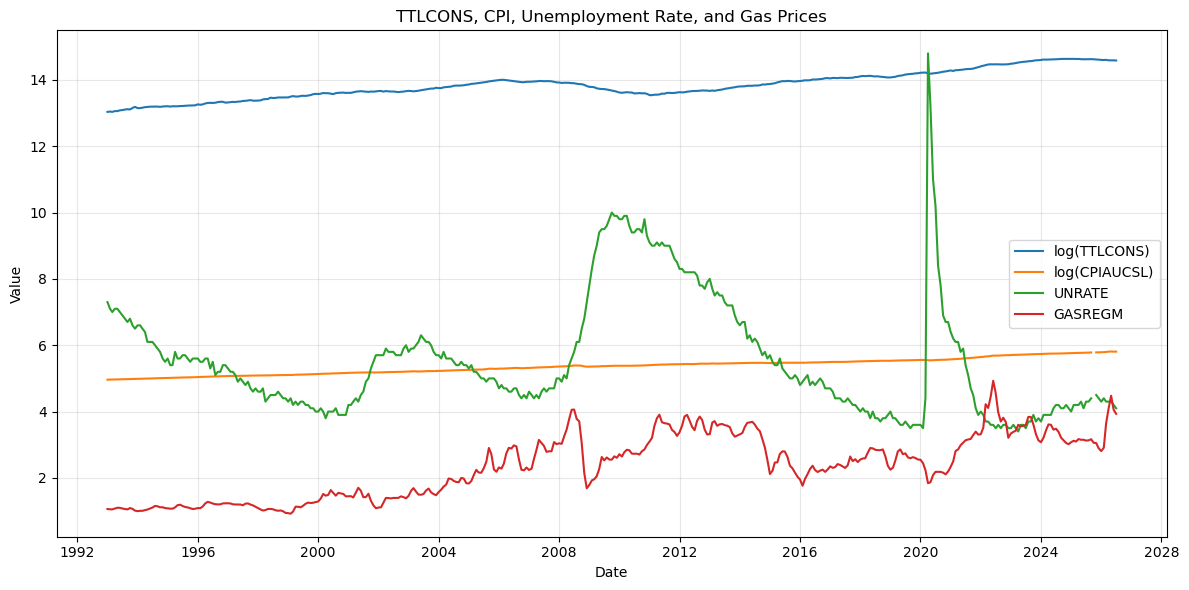

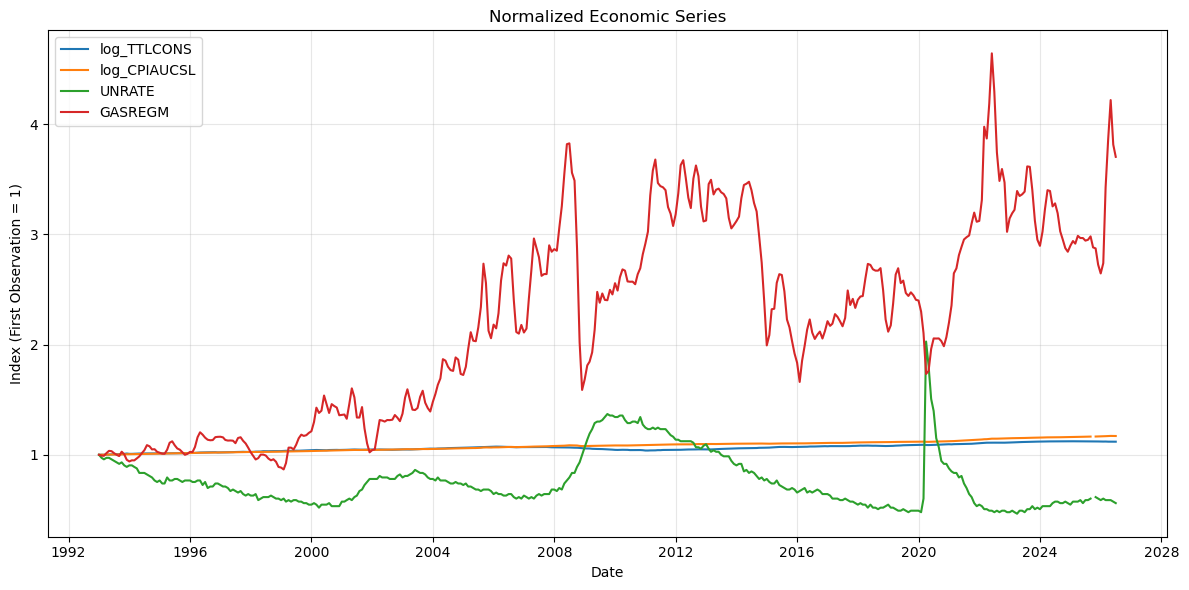

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["log_TTLCONS"], label="log(TTLCONS)")
plt.plot(df["date"], df["log_CPIAUCSL"], label="log(CPIAUCSL)")
plt.plot(df["date"], df["UNRATE"], label="UNRATE")
plt.plot(df["date"], df["GASREGM"], label="GASREGM")

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("TTLCONS, CPI, Unemployment Rate, and Gas Prices")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plot_df = df.set_index("date")[
    ["log_TTLCONS", "log_CPIAUCSL", "UNRATE", "GASREGM"]
].copy()

# Normalize each series to its first observation
plot_df = plot_df / plot_df.iloc[0]

plt.figure(figsize=(12, 6))

for column in plot_df.columns:
    plt.plot(plot_df.index, plot_df[column], label=column)

plt.xlabel("Date")
plt.ylabel("Index (First Observation = 1)")
plt.title("Normalized Economic Series")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Created with the help of AT ChatGPT free. Sort of left it in as a way to show thought process and how I began to isolate quality insights. 

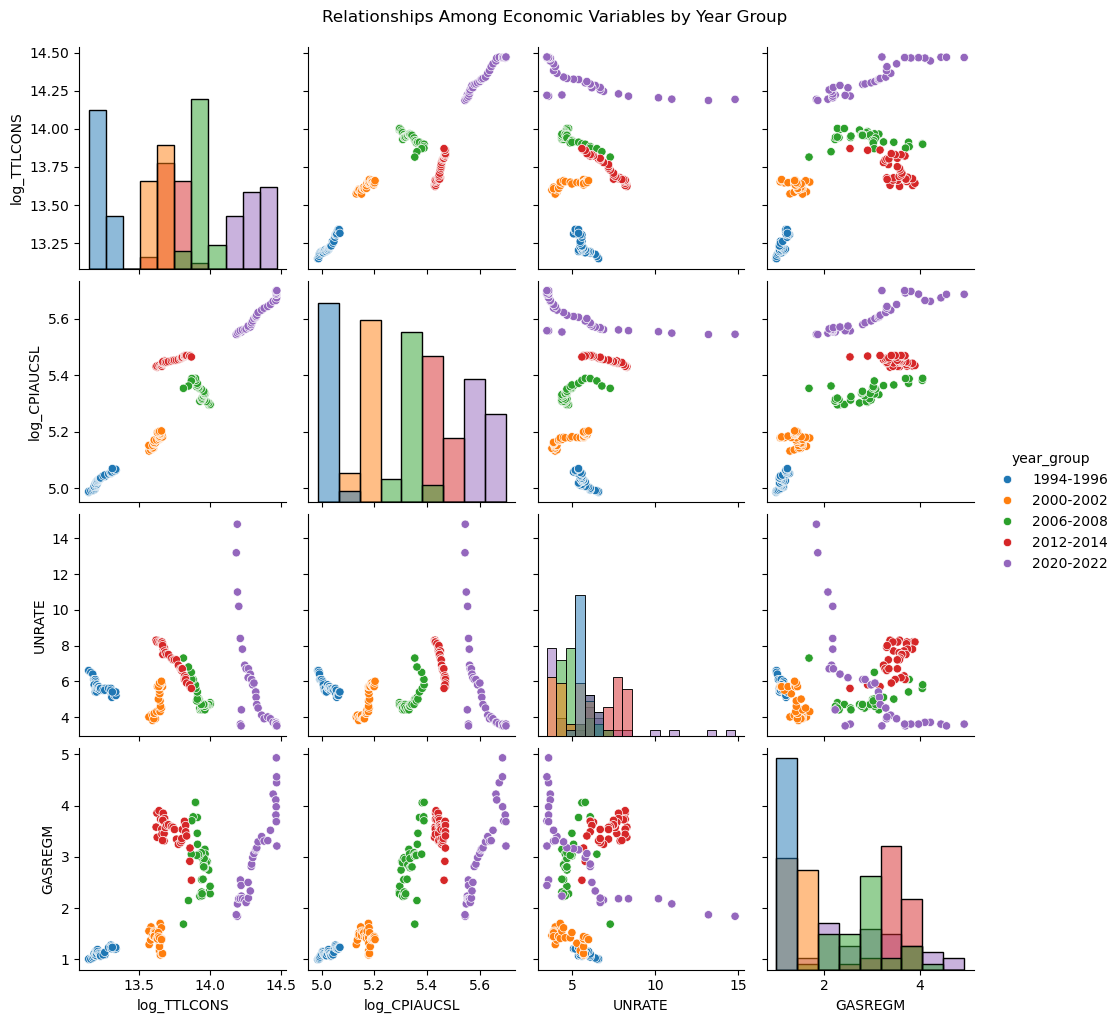

In [44]:
# Create year column
df["year"] = df["date"].dt.year

# Create year groups
def assign_year_group(year):
    if 1994 <= year <= 1996:
        return "1994-1996"
    elif 2000 <= year <= 2002:
        return "2000-2002"
    elif 2006 <= year <= 2008:
        return "2006-2008"
    elif 2012 <= year <= 2014:
        return "2012-2014"
    elif 2020 <= year <= 2022:
        return "2020-2022"
    else:
        return np.nan

df["year_group"] = df["year"].apply(assign_year_group)

# Keep only the requested year groups
plot_df = df.dropna(subset=["year_group"]).copy()

# Variables to plot
variables = [
    "log_TTLCONS",
    "log_CPIAUCSL",
    "UNRATE",
    "GASREGM"
]

# Create scatterplot matrix
sns.pairplot(
    plot_df,
    vars=variables,
    hue="year_group",
    diag_kind="hist",
    height=2.5
)

plt.suptitle(
    "Relationships Among Economic Variables by Year Group",
    y=1.02
)

plt.show()

In [45]:
plot_df.head()

,date,TTLCONS,log_TTLCONS,CPIAUCSL,UNRATE,GASREGM,log_CPIAUCSL,year,year_group
12,1994-01-01,513314.0,13.148643,146.3,6.6,0.998,4.985659,1994,1994-1996
13,1994-02-01,513196.0,13.148413,146.7,6.6,1.009,4.988390,1994,1994-1996
14,1994-03-01,521040.0,13.163582,147.1,6.5,1.008,4.991113,1994,1994-1996
15,1994-04-01,528063.0,13.176971,147.2,6.4,1.027,4.991792,1994,1994-1996
16,1994-05-01,532328.0,13.185015,147.5,6.1,1.047,4.993828,1994,1994-1996


The next two plots should look very familiar as one is used in the final. AI was utilized in the creation but showed progress working with the agent for a quality output.

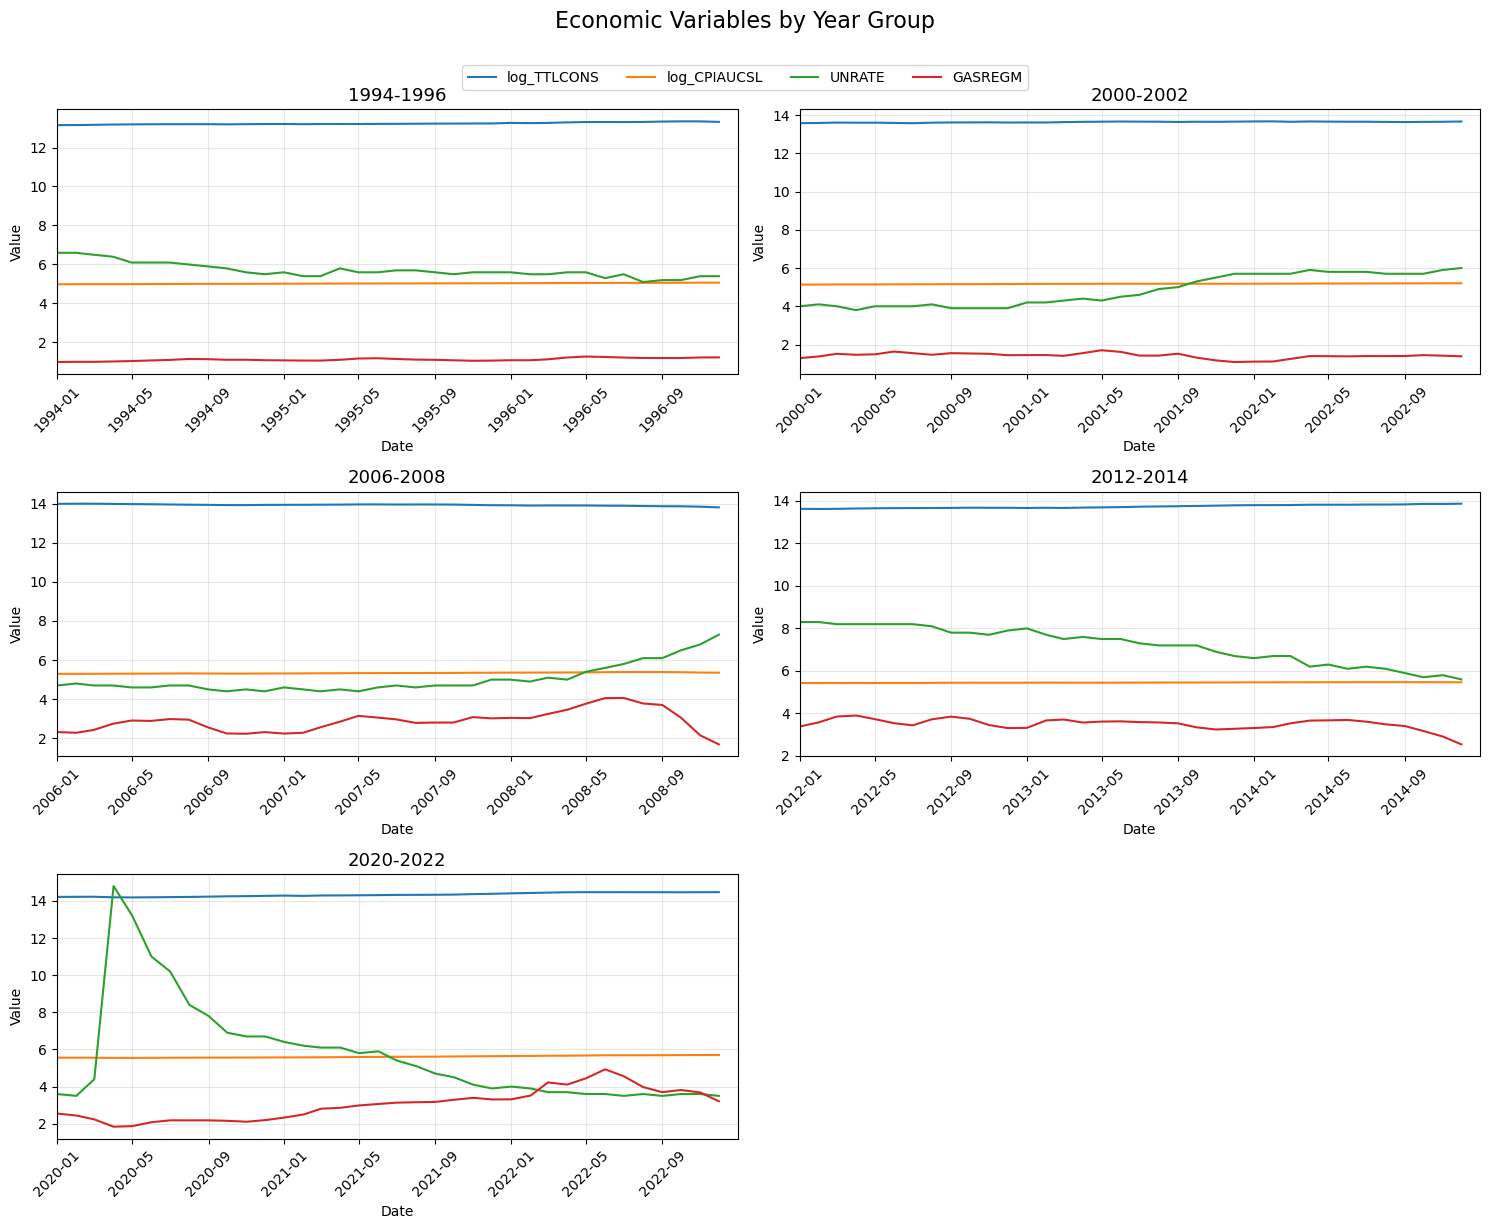

In [46]:
variables = [
    "log_TTLCONS",
    "log_CPIAUCSL",
    "UNRATE",
    "GASREGM"
]

# Make sure observations are sorted
plot_df = plot_df.sort_values(["year_group", "date"]).copy()

# Year groups in the desired order
year_order = [
    "1994-1996",
    "2000-2002",
    "2006-2008",
    "2012-2014",
    "2020-2022"
]

# Create figure
fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 12),
    sharey=False
)

# Flatten axes so we can loop through them
axes = axes.flatten()

# Plot each year group
for ax, year_group in zip(axes, year_order):

    # Get data for this year group
    group_data = plot_df[
        plot_df["year_group"] == year_group
    ].copy()

    # Convert to long format
    group_long = group_data.melt(
        id_vars=["date"],
        value_vars=variables,
        var_name="Variable",
        value_name="Value"
    )

    # Create line plot
    sns.lineplot(
        data=group_long,
        x="date",
        y="Value",
        hue="Variable",
        ax=ax
    )

    # Set title
    ax.set_title(year_group, fontsize=13)

    # Set x-axis limits to the actual year group
    start_year = int(year_group[:4])
    end_year = int(year_group[-4:])

    ax.set_xlim(
        pd.Timestamp(f"{start_year}-01-01"),
        pd.Timestamp(f"{end_year}-12-31")
    )

    # Labels
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")

    # Rotate dates
    ax.tick_params(axis="x", rotation=45)

    # Grid
    ax.grid(True, alpha=0.3)

# Remove the unused 6th subplot
fig.delaxes(axes[-1])

# Create one overall legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
for ax in axes[:-1]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.98)
)

# Overall title
fig.suptitle(
    "Economic Variables by Year Group",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

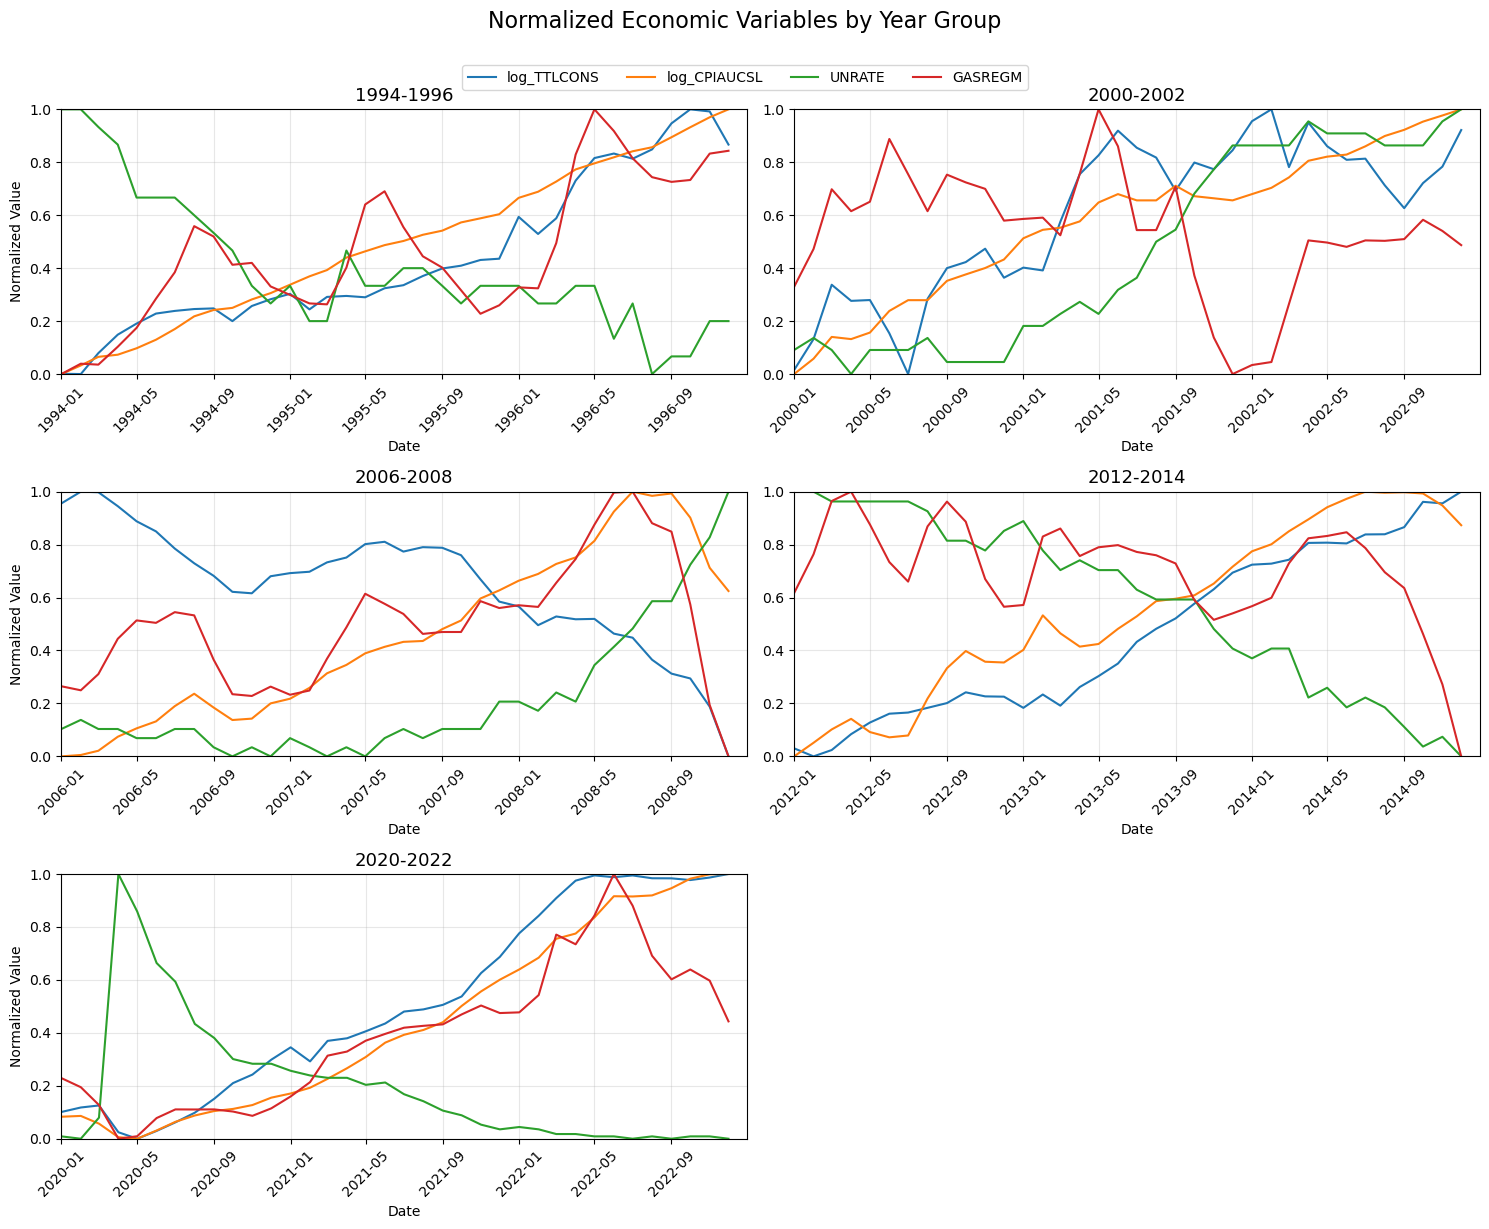

In [47]:
variables = [
    "log_TTLCONS",
    "log_CPIAUCSL",
    "UNRATE",
    "GASREGM"
]

# Make sure observations are sorted
plot_df = plot_df.sort_values(["year_group", "date"]).copy()

# Normalize each variable within each year group
for variable in variables:
    plot_df[variable + "_normalized"] = (
        plot_df.groupby("year_group")[variable]
        .transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
    )

# Normalized variable names
normalized_variables = [
    variable + "_normalized"
    for variable in variables
]

# Year groups in desired order
year_order = [
    "1994-1996",
    "2000-2002",
    "2006-2008",
    "2012-2014",
    "2020-2022"
]

# Create figure
fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 12),
    sharey=True
)

axes = axes.flatten()

# Plot each year group
for ax, year_group in zip(axes, year_order):

    # Select year group
    group_data = plot_df[
        plot_df["year_group"] == year_group
    ].copy()

    # Convert normalized data to long format
    group_long = group_data.melt(
        id_vars=["date"],
        value_vars=normalized_variables,
        var_name="Variable",
        value_name="Normalized Value"
    )

    # Clean variable names
    group_long["Variable"] = (
        group_long["Variable"]
        .str.replace("_normalized", "", regex=False)
    )

    # Create line plot
    sns.lineplot(
        data=group_long,
        x="date",
        y="Normalized Value",
        hue="Variable",
        ax=ax
    )

    # Get start/end years
    start_year = int(year_group[:4])
    end_year = int(year_group[-4:])

    # Set x-axis limits
    ax.set_xlim(
        pd.Timestamp(f"{start_year}-01-01"),
        pd.Timestamp(f"{end_year}-12-31")
    )

    # Set y-axis limits
    ax.set_ylim(0, 1)

    # Titles and labels
    ax.set_title(year_group, fontsize=13)
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalized Value")

    # Make sure y-axis is displayed on EVERY plot
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelleft=True
    )

    # Rotate x-axis labels
    ax.tick_params(axis="x", rotation=45)

    # Add grid
    ax.grid(True, alpha=0.3)

# Remove unused sixth subplot
fig.delaxes(axes[-1])

# Get legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
for ax in axes[:-1]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Add one overall legend
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.98)
)

# Overall title
fig.suptitle(
    "Normalized Economic Variables by Year Group",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

More quality output after continued practice using an agent

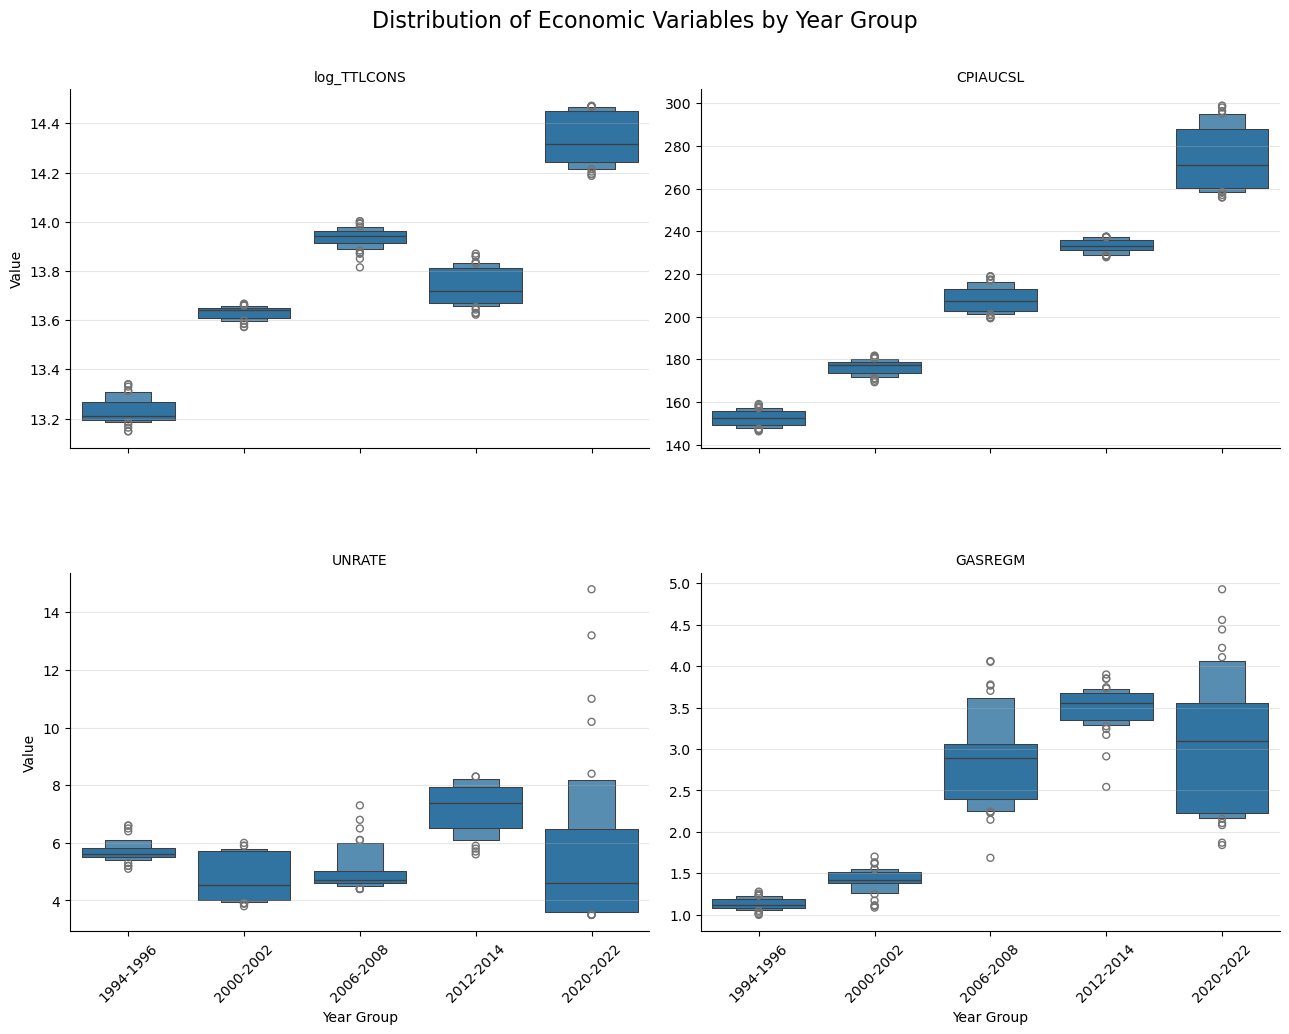

In [48]:
variables = [
    "log_TTLCONS",
    "CPIAUCSL",
    "UNRATE",
    "GASREGM"
]

# Define the five year groups
year_order = [
    "1994-1996",
    "2000-2002",
    "2006-2008",
    "2012-2014",
    "2020-2022"
]

# Make sure group_data contains ALL five year groups
group_data = plot_df[
    plot_df["year_group"].isin(year_order)
].copy()

# Make year_group categorical and ordered
group_data["year_group"] = pd.Categorical(
    group_data["year_group"],
    categories=year_order,
    ordered=True
)

# Convert to long format
boxen_df = group_data.melt(
    id_vars=["year_group"],
    value_vars=variables,
    var_name="Variable",
    value_name="Value"
)

# Remove missing values
boxen_df = boxen_df.dropna(subset=["Value"])

# Create the 4 plots
g = sns.FacetGrid(
    boxen_df,
    col="Variable",
    col_wrap=2,
    height=5,
    aspect=1.3,
    sharey=False,
    col_order=variables
)

# Create boxenplots
g.map_dataframe(
    sns.boxenplot,
    x="year_group",
    y="Value",
    order=year_order
)

# Set labels and titles
g.set_axis_labels("Year Group", "Value")
g.set_titles("{col_name}")

# Force all 5 year groups onto EVERY plot
for ax in g.axes.flat:
    ax.set_xticks(range(len(year_order)))
    ax.set_xticklabels(year_order, rotation=45)
    ax.set_xlabel("Year Group")
    ax.grid(axis="y", alpha=0.3)

# Overall title
g.figure.suptitle(
    "Distribution of Economic Variables by Year Group",
    fontsize=16
)

plt.subplots_adjust(
    top=0.90,
    hspace=0.35
)

plt.show()

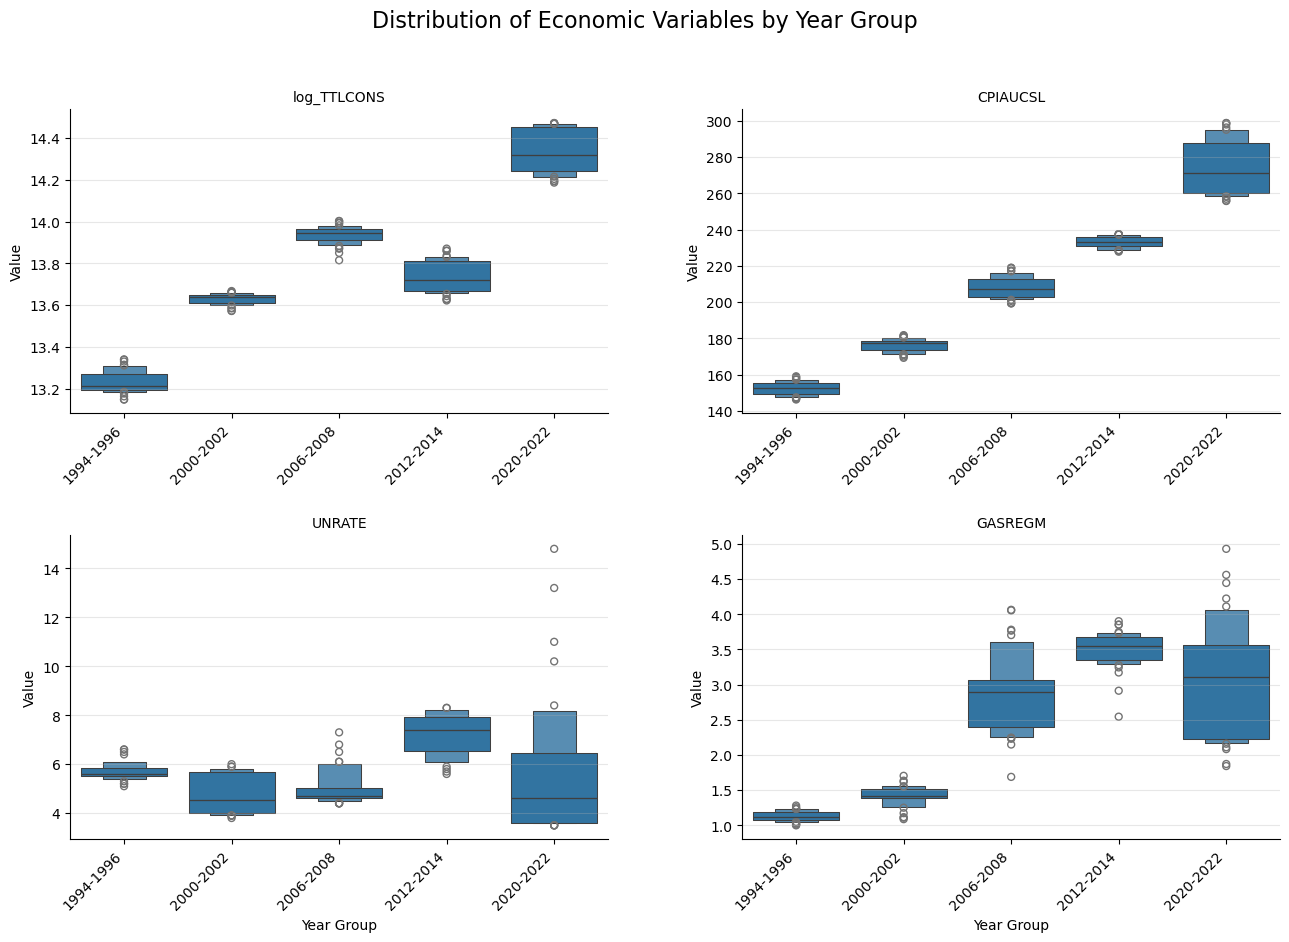

In [49]:
variables = [
    "log_TTLCONS",
    "CPIAUCSL",
    "UNRATE",
    "GASREGM"
]

# Convert to long format
boxen_df = group_data.melt(
    id_vars=["year_group"],
    value_vars=variables,
    var_name="Variable",
    value_name="Value"
)

g = sns.FacetGrid(
    boxen_df,
    col="Variable",
    col_wrap=2,
    height=5,
    aspect=1.3,
    sharey=False,
    col_order=variables
)

# Create boxenplots
g.map_dataframe(
    sns.boxenplot,
    x="year_group",
    y="Value",
    order=year_order
)

# Set labels and titles
g.set_axis_labels("Year Group", "Value")
g.set_titles("{col_name}")

# Force BOTH axes to be visible on every plot
for ax in g.axes.flat:

    # X-axis
    ax.set_xlabel("Year Group")
    ax.set_xticks(range(len(year_order)))
    ax.set_xticklabels(
        year_order,
        rotation=45,
        ha="right"
    )

    # Explicitly show x-axis and labels
    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelbottom=True
    )

    # Y-axis
    ax.set_ylabel("Value")
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelleft=True
    )

    # Grid
    ax.grid(
        axis="y",
        alpha=0.3
    )

# Overall title
g.figure.suptitle(
    "Distribution of Economic Variables by Year Group",
    fontsize=16
)

# Give enough room for x-axis labels
plt.subplots_adjust(
    top=0.88,
    bottom=0.15,
    hspace=0.40,
    wspace=0.25
)

plt.show()